In [23]:
"""
Video Game Recommender Intelligence Platform (Steam + RAWG)
University ML Course Project Notebook

This notebook covers:
- Data engineering and Steam+RAWG fusion
- EDA with report-quality visualizations
- Classification, regression, dimensionality reduction
- Hybrid recommendation (content + collaborative)
- Persona-aware and explainable recommendations
- Time-series, clustering, and association rules
"""

'\nVideo Game Recommender Intelligence Platform (Steam + RAWG)\nUniversity ML Course Project Notebook\n\nThis notebook covers:\n- Data engineering and Steam+RAWG fusion\n- EDA with report-quality visualizations\n- Classification, regression, dimensionality reduction\n- Hybrid recommendation (content + collaborative)\n- Persona-aware and explainable recommendations\n- Time-series, clustering, and association rules\n'

In [24]:
# !pip install -q xgboost mlxtend

import ast
import json
import random
import warnings
from datetime import datetime

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA, TruncatedSVD, NMF
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neural_network import MLPClassifier
from sklearn.impute import SimpleImputer

try:
    from xgboost import XGBClassifier, XGBRegressor
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost", "-q"])
    from xgboost import XGBClassifier, XGBRegressor

try:
    from mlxtend.preprocessing import TransactionEncoder
    from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "mlxtend", "-q"])
    from mlxtend.preprocessing import TransactionEncoder
    from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth

from scipy.sparse import hstack, csr_matrix
from scipy.spatial.distance import cdist
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose

warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13

print("Environment ready.")

Environment ready.


## 1) Data Loading and Engineering

We load both data sources, standardize schemas, and create a merged game intelligence table.

**Design goals:**
- Keep processing reproducible and memory-safe
- Preserve rich metadata (genres, tags, descriptions, publishers, ratings)
- Build features that support multiple ML tasks and recommendation explainability


In [34]:
# Paths
steam_path = "Datasets/Steam Dataset/games.csv"
rawg_path = "Datasets/RAWG Dataset/rawg-games-dataset.csv"

# Adjustable sample sizes for practical runtime
STEAM_SAMPLE_N = 7000
RAWG_SAMPLE_N = 12000

steam_df = pd.read_csv(steam_path)
rawg_df = pd.read_csv(rawg_path)

if STEAM_SAMPLE_N and len(steam_df) > STEAM_SAMPLE_N:
    steam_df = steam_df.sample(STEAM_SAMPLE_N, random_state=42).reset_index(drop=True)
if RAWG_SAMPLE_N and len(rawg_df) > RAWG_SAMPLE_N:
    rawg_df = rawg_df.sample(RAWG_SAMPLE_N, random_state=42).reset_index(drop=True)

print("Steam shape:", steam_df.shape)
print("RAWG shape:", rawg_df.shape)


def normalize_name(x):
    if pd.isna(x):
        return ""
    x = str(x).lower().strip()
    x = "".join(ch if ch.isalnum() or ch.isspace() else " " for ch in x)
    return " ".join(x.split())


def parse_pipe_or_csv(text):
    if pd.isna(text):
        return []
    text = str(text).strip()
    if not text:
        return []
    if "|" in text:
        return [t.strip().lower() for t in text.split("|") if t.strip()]
    if "," in text:
        return [t.strip().lower() for t in text.split(",") if t.strip()]
    return [text.lower()]


def parse_steam_text_list(text):
    if pd.isna(text):
        return []
    text = str(text).strip()
    if not text or text == "[]":
        return []
    # Handles formats like "['English', 'French']"
    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, list):
            return [str(x).strip().lower() for x in parsed if str(x).strip()]
    except Exception:
        pass
    return parse_pipe_or_csv(text)


def safe_json_name(text):
    if pd.isna(text):
        return np.nan
    try:
        obj = json.loads(str(text).replace("'", '"'))
        if isinstance(obj, dict):
            return obj.get("name", np.nan)
    except Exception:
        pass
    return np.nan


Steam shape: (7000, 39)
RAWG shape: (12000, 54)


In [35]:
# --- Steam cleaning ---
steam = steam_df.copy()
steam.columns = [c.strip().lower().replace(" ", "_") for c in steam.columns]

steam["game_name"] = steam["name"].fillna("")
steam["game_key"] = steam["game_name"].map(normalize_name)

steam["genres_list"] = steam["genres"].apply(parse_pipe_or_csv)
steam["tags_list"] = steam["tags"].apply(parse_pipe_or_csv)
steam["about_text"] = steam["about_the_game"].fillna("")

steam["release_date"] = pd.to_datetime(steam["release_date"], errors="coerce")
steam["release_year"] = steam["release_date"].dt.year
steam["release_month"] = steam["release_date"].dt.month

steam["reviews_total"] = steam["positive"].fillna(0) + steam["negative"].fillna(0)

steam["review_ratio"] = (
    steam["positive"].fillna(0) /
    steam["reviews_total"].replace(0, np.nan)
)
steam["review_ratio"] = steam["review_ratio"].fillna(0)


# Approximate owner midpoint from ranges like "0 - 20000"
def parse_owner_mid(x):
    if pd.isna(x):
        return np.nan

    txt = str(x).replace(",", "").strip()

    if "-" in txt:
        try:
            lo, hi = [float(v.strip()) for v in txt.split("-")]
            return (lo + hi) / 2
        except:
            return np.nan

    try:
        return float(txt)
    except:
        return np.nan


steam["estimated_owners_mid"] = steam["estimated_owners"].apply(parse_owner_mid)

steam_features = steam[[
    "appid",
    "game_name",
    "game_key",
    "price",
    "required_age",
    "peak_ccu",
    "metacritic_score",
    "user_score",
    "positive",
    "negative",
    "reviews_total",
    "review_ratio",
    "recommendations",
    "average_playtime_forever",
    "median_playtime_forever",
    "developers",
    "publishers",
    "genres",
    "tags",
    "genres_list",
    "tags_list",
    "about_text",
    "release_date",
    "release_year",
    "release_month",
    "estimated_owners_mid"
]].copy()


# --- RAWG cleaning ---
rawg = rawg_df.copy()
rawg.columns = [c.strip().lower().replace(" ", "_") for c in rawg.columns]

# Safely fill name from name_original fallback
_rawg_name_fallback = rawg["name_original"] if "name_original" in rawg.columns else pd.Series("", index=rawg.index)
rawg["game_name"] = rawg["name"].fillna(_rawg_name_fallback).fillna("")

rawg["game_key"] = rawg["game_name"].map(normalize_name)

rawg["genres_list"] = rawg["genres"].apply(parse_pipe_or_csv)
rawg["tags_list"] = rawg["tags"].apply(parse_pipe_or_csv)

# Safely fill description from description/description_raw
_rawg_desc_fallback = rawg["description"] if "description" in rawg.columns else pd.Series("", index=rawg.index)
rawg["description_text"] = rawg["description_raw"].fillna(_rawg_desc_fallback).fillna("")

rawg["released"] = pd.to_datetime(rawg["released"], errors="coerce")
rawg["rawg_release_year"] = rawg["released"].dt.year
rawg["rawg_release_month"] = rawg["released"].dt.month

rawg["updated"] = pd.to_datetime(rawg["updated"], errors="coerce")
rawg["days_to_update"] = (
    rawg["updated"] - rawg["released"]
).dt.days

rawg["esrb_name"] = rawg["esrb_rating"].apply(safe_json_name)

rawg_features = rawg[[
    "id",
    "game_name",
    "game_key",
    "rating",
    "ratings_count",
    "reviews_count",
    "playtime",
    "suggestions_count",
    "metacritic",
    "developers",
    "publishers",
    "genres",
    "tags",
    "genres_list",
    "tags_list",
    "description_text",
    "released",
    "rawg_release_year",
    "rawg_release_month",
    "updated",
    "days_to_update",
    "esrb_name"
]].copy()


# --- Merge strategy: normalized name join ---
merged = steam_features.merge(
    rawg_features,
    on="game_key",
    how="outer",
    suffixes=("_steam", "_rawg")
)


# IMPORTANT FIX: restore single game_name column
merged["game_name"] = merged["game_name_steam"].fillna(
    merged["game_name_rawg"]
)


# IMPORTANT FIX: force list columns to always be lists
list_cols = [
    "genres_list_steam",
    "genres_list_rawg",
    "tags_list_steam",
    "tags_list_rawg"
]

for col in list_cols:
    if col in merged.columns:
        merged[col] = merged[col].apply(
            lambda x: x if isinstance(x, list) else []
        )


# Prefer Steam genres/tags if available, otherwise RAWG
merged["genres_list"] = merged["genres_list_steam"].where(
    merged["genres_list_steam"].apply(lambda x: len(x) > 0),
    merged["genres_list_rawg"]
)

merged["tags_list"] = merged["tags_list_steam"].where(
    merged["tags_list_steam"].apply(lambda x: len(x) > 0),
    merged["tags_list_rawg"]
)


# Combine descriptions
merged["description"] = (
    merged["about_text"].fillna("") + " " +
    merged["description_text"].fillna("")
)


# Final release date fields
merged["release_date_final"] = merged["release_date"].fillna(
    merged["released"]
)

merged["release_year_final"] = merged["release_year"].fillna(
    merged["rawg_release_year"]
)

merged["release_month_final"] = merged["release_month"].fillna(
    merged["rawg_release_month"]
)


# Remove duplicate game keys while keeping richest records
merged["info_completeness"] = merged[[
    "price",
    "rating",
    "metacritic",
    "metacritic_score",
    "reviews_total",
    "ratings_count"
]].notna().sum(axis=1)

merged = (
    merged
    .sort_values("info_completeness", ascending=False)
    .drop_duplicates("game_key")
)


# Fill numeric nulls safely
# NOTE: review_ratio is intentionally excluded from median fill.
# Games without Steam reviews should stay NaN here so that feature engineering
# in Cell 10 can substitute the RAWG rating as a quality signal instead of
# propagating a meaningless global median into every reception label.
numeric_fill_cols = [
    "price", "required_age", "peak_ccu", "metacritic_score", "user_score",
    "positive", "negative", "reviews_total", "recommendations",
    "average_playtime_forever", "median_playtime_forever", "estimated_owners_mid",
    "rating", "ratings_count", "reviews_count", "playtime",
    "suggestions_count", "metacritic", "days_to_update",
]

for col in numeric_fill_cols:
    if col in merged.columns and pd.api.types.is_numeric_dtype(merged[col]):
        merged[col] = merged[col].fillna(merged[col].median())

# review_ratio: fill only Steam games (reviews_total > 0); leave RAWG-only rows as NaN
has_steam_reviews = merged["reviews_total"] > 0
steam_ratio = merged["positive"] / merged["reviews_total"].replace(0, np.nan)
merged["review_ratio"] = steam_ratio.where(has_steam_reviews, np.nan)


merged["release_year_final"] = merged["release_year_final"].fillna(
    merged["release_year_final"].median()
)

merged["release_month_final"] = merged["release_month_final"].fillna(1)


print("Merged shape:", merged.shape)
print("Unique games:", merged["game_key"].nunique())

merged[[
    "game_name",
    "price",
    "rating",
    "metacritic",
    "review_ratio",
    "genres_list",
    "tags_list"
]].head()

Merged shape: (14881, 55)
Unique games: 14881


,game_name,price,rating,metacritic,review_ratio,genres_list,tags_list
7792,"Jan 23, 2023",0.0,3.56,75.0,NaN,"[casual, indie]",[]
7777,"Jan 22, 2025",55.0,3.56,75.0,0.776000,"[casual, indie, racing, simulation, sports]","[relaxing, realistic, education, resource mana..."
7781,"Jan 23, 2009",0.0,3.56,75.0,0.782051,"[strategy, indie]","[strategy, indie, tower defense, sci-fi, singl..."
7782,"Jan 23, 2018",75.0,3.56,75.0,0.970488,"[adventure, indie]","[open world survival craft, survival, horror, ..."
7784,"Jan 23, 2019",80.0,3.56,75.0,0.916667,"[adventure, indie]","[indie, adventure, platformer, exploration, pu..."


## 2) Exploratory Data Analysis (EDA)

This section creates report-quality visuals to understand:
- Dataset quality and missingness
- Genre/tag ecosystem
- Reception and popularity patterns
- Temporal and seasonal trends


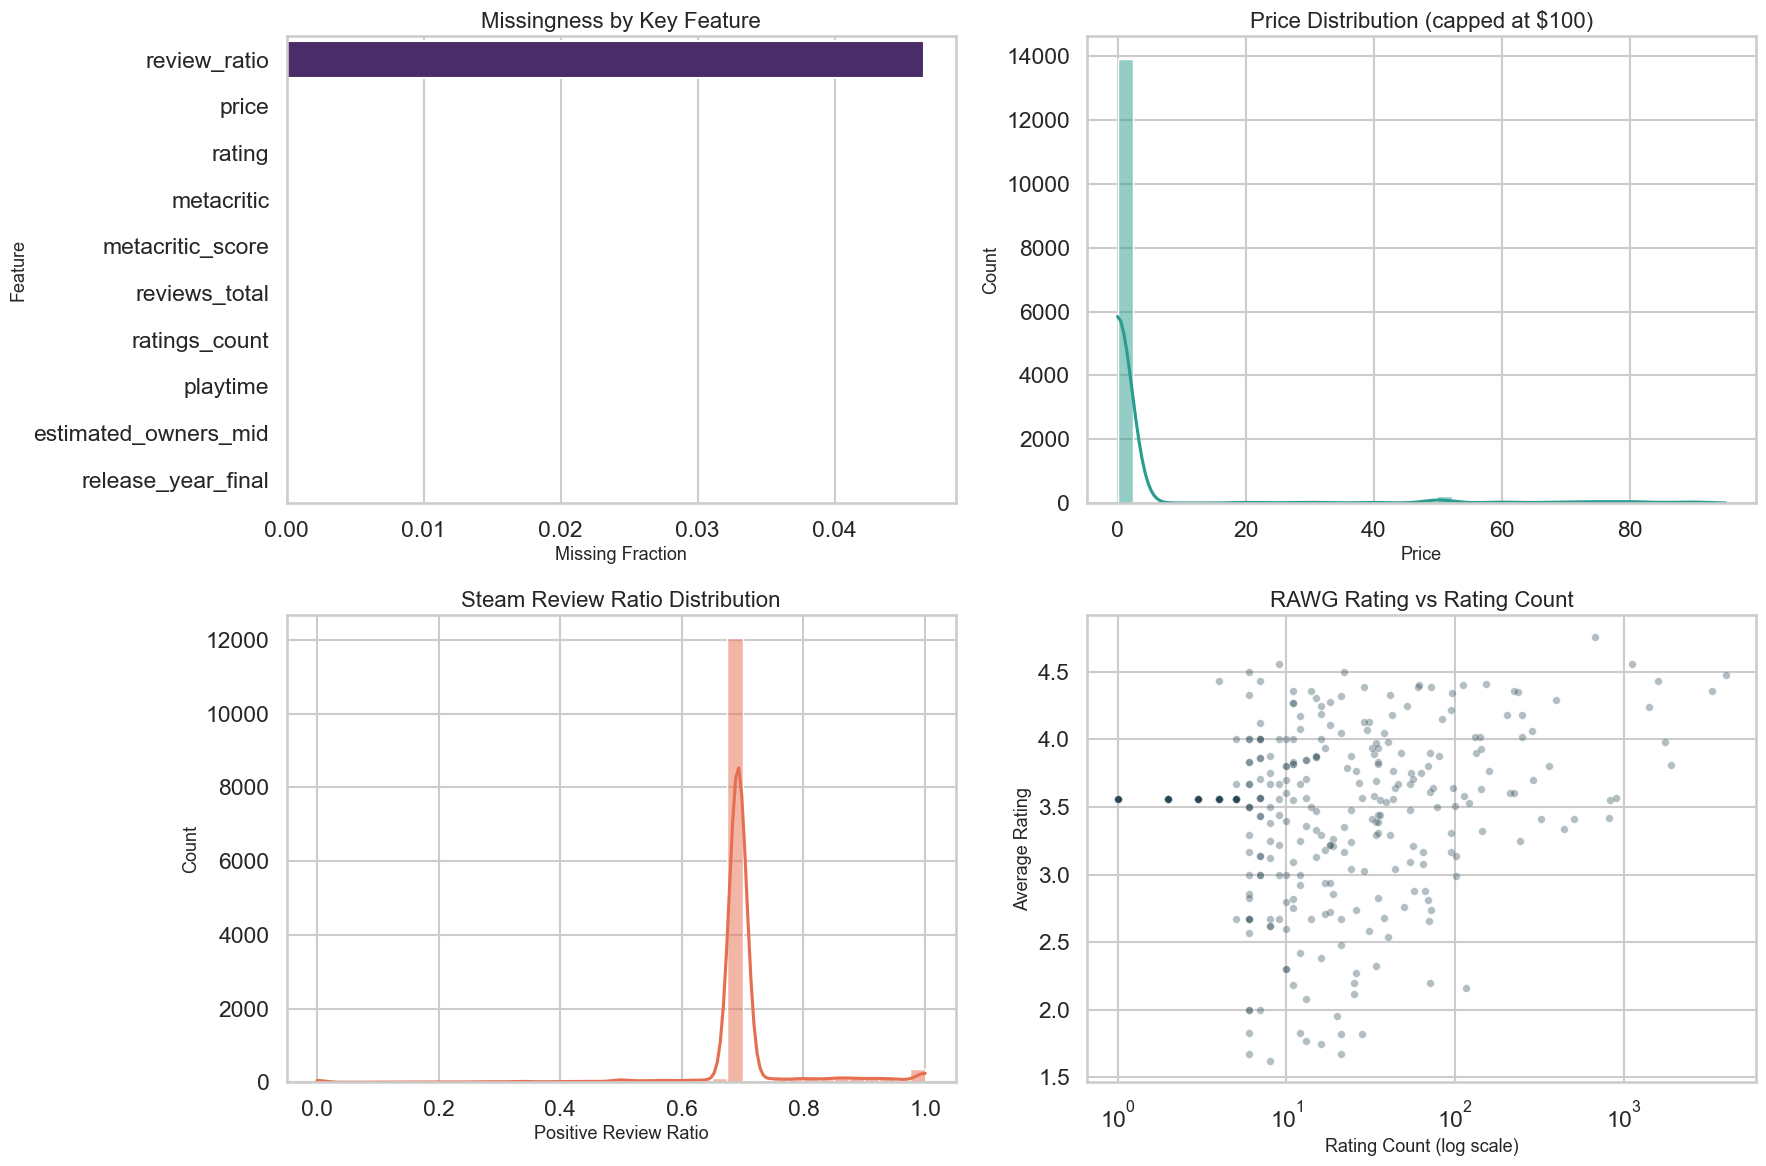

In [36]:
# Missingness and key distribution overview
key_cols = [
    "price", "rating", "metacritic", "metacritic_score", "review_ratio", "reviews_total",
    "ratings_count", "playtime", "estimated_owners_mid", "release_year_final"
]

missing_df = merged[key_cols].isna().mean().sort_values(ascending=False).rename("missing_pct").reset_index()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.barplot(data=missing_df, x="missing_pct", y="index", ax=axes[0, 0], palette="viridis")
axes[0, 0].set_title("Missingness by Key Feature")
axes[0, 0].set_xlabel("Missing Fraction")
axes[0, 0].set_ylabel("Feature")

sns.histplot(merged["price"].clip(upper=100), bins=40, kde=True, ax=axes[0, 1], color="#2a9d8f")
axes[0, 1].set_title("Price Distribution (capped at $100)")
axes[0, 1].set_xlabel("Price")

sns.histplot(merged["review_ratio"], bins=40, kde=True, ax=axes[1, 0], color="#e76f51")
axes[1, 0].set_title("Steam Review Ratio Distribution")
axes[1, 0].set_xlabel("Positive Review Ratio")

sns.scatterplot(
    data=merged.sample(min(15000, len(merged)), random_state=42),
    x="ratings_count",
    y="rating",
    alpha=0.35,
    s=30,
    ax=axes[1, 1],
    color="#264653"
)
axes[1, 1].set_xscale("log")
axes[1, 1].set_title("RAWG Rating vs Rating Count")
axes[1, 1].set_xlabel("Rating Count (log scale)")
axes[1, 1].set_ylabel("Average Rating")

plt.tight_layout()
plt.show()

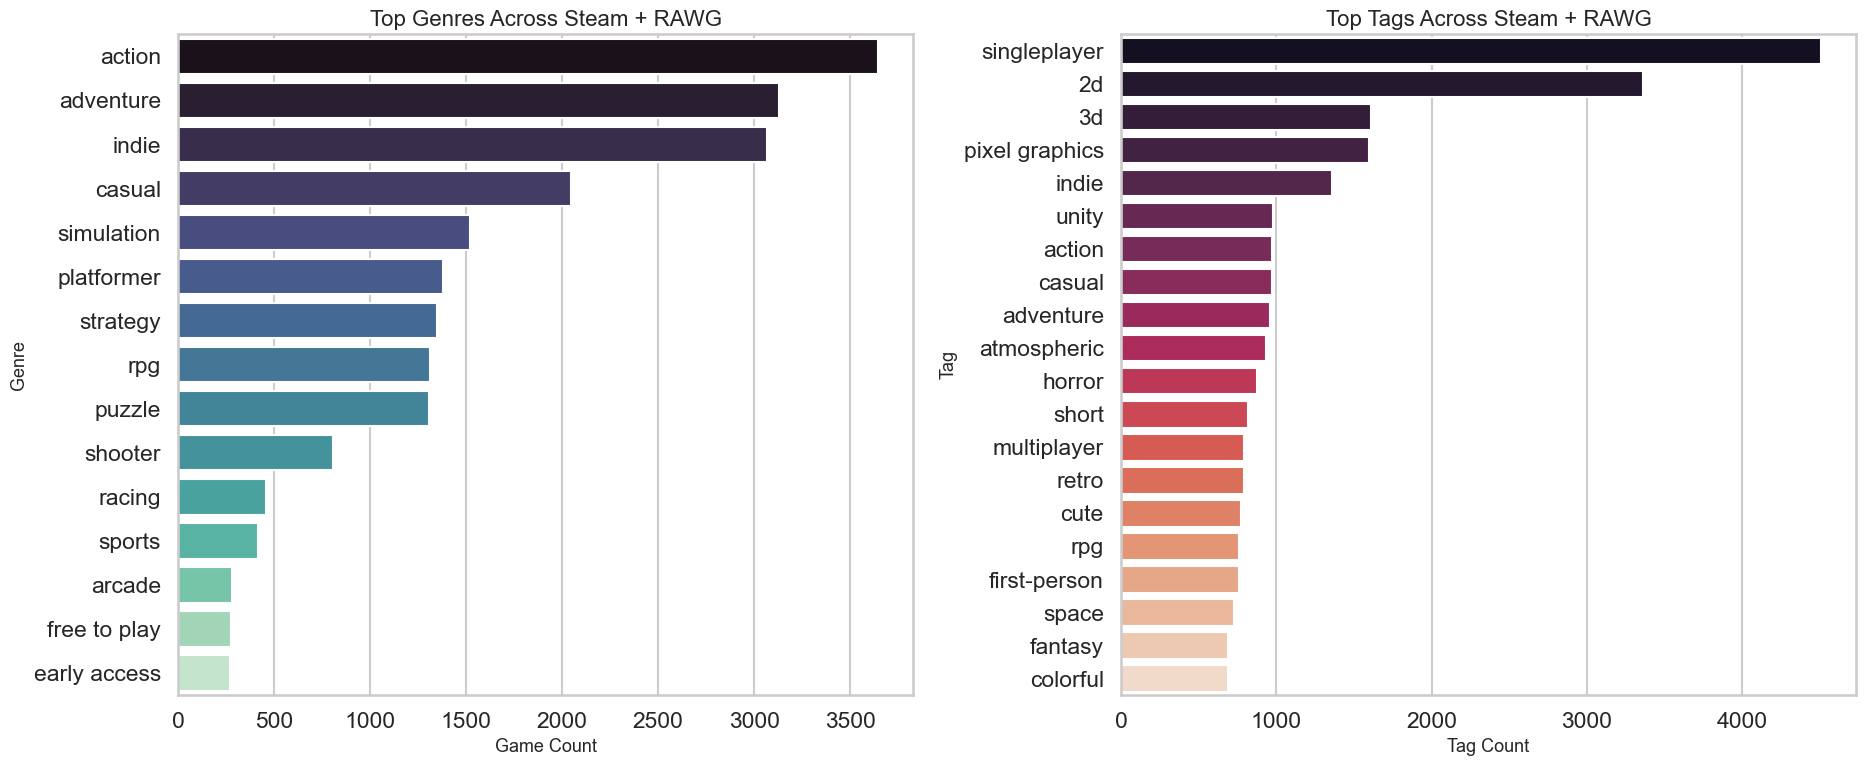

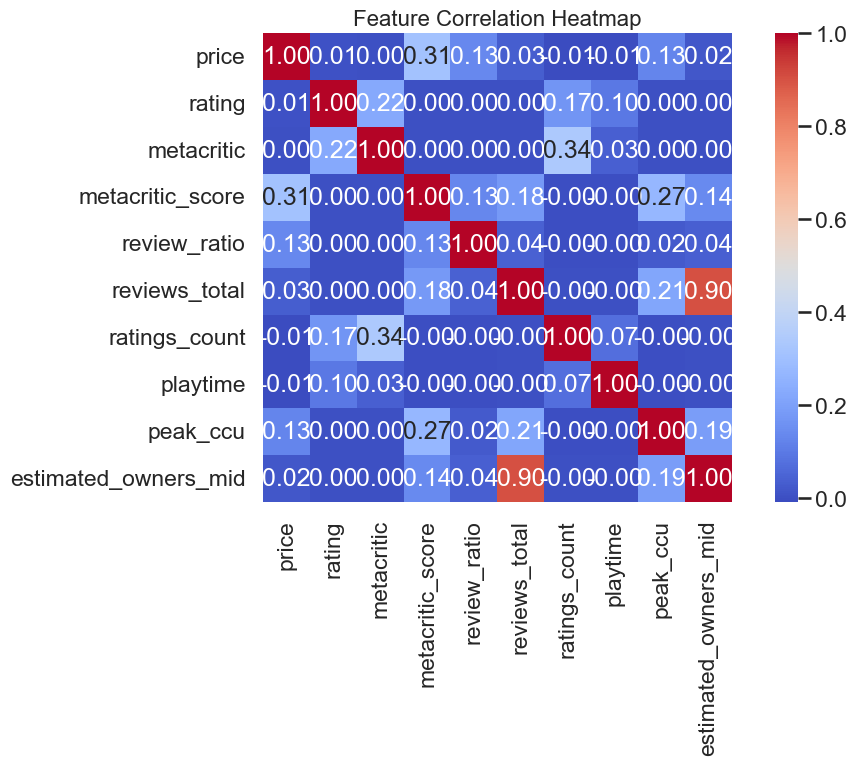

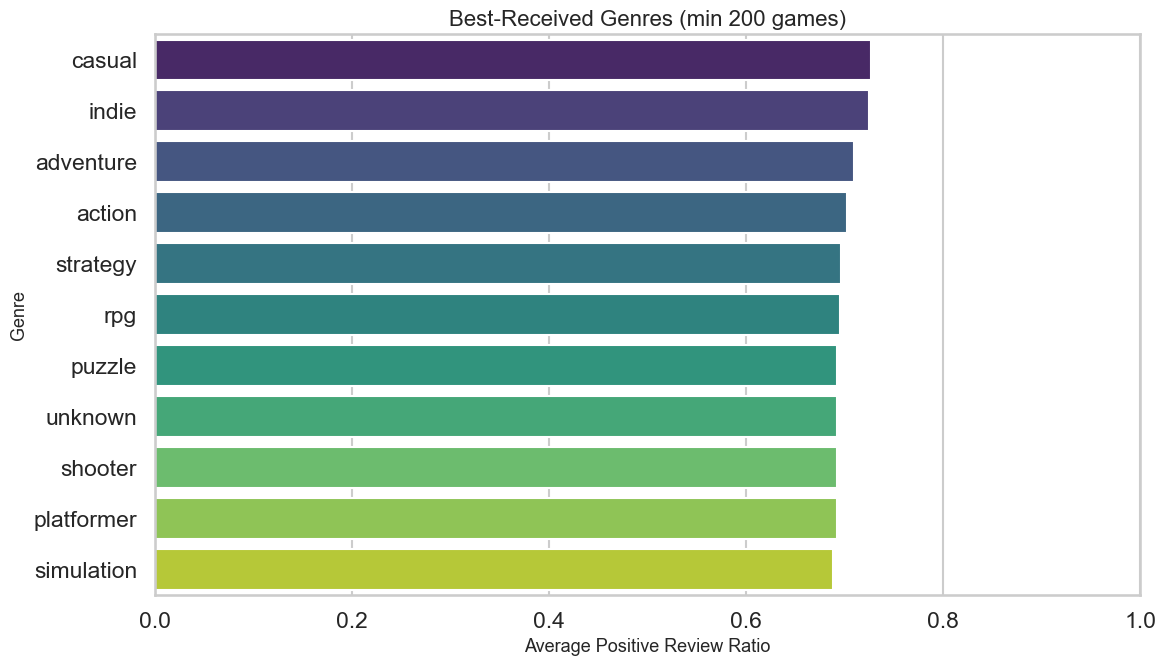

In [37]:
# Genre, tags, and correlation-driven insights

def flatten_top(series_of_lists, n=15):
    exploded = series_of_lists.explode().dropna().astype(str).str.strip().str.lower()
    exploded = exploded[exploded != ""]
    return exploded.value_counts().head(n)

top_genres = flatten_top(merged["genres_list"], n=15)
top_tags = flatten_top(merged["tags_list"], n=20)

fig, axes = plt.subplots(1, 2, figsize=(19, 8))

sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[0], palette="mako")
axes[0].set_title("Top Genres Across Steam + RAWG")
axes[0].set_xlabel("Game Count")
axes[0].set_ylabel("Genre")

sns.barplot(x=top_tags.values, y=top_tags.index, ax=axes[1], palette="rocket")
axes[1].set_title("Top Tags Across Steam + RAWG")
axes[1].set_xlabel("Tag Count")
axes[1].set_ylabel("Tag")

plt.tight_layout()
plt.show()

corr_cols = ["price", "rating", "metacritic", "metacritic_score", "review_ratio", "reviews_total", "ratings_count", "playtime", "peak_ccu", "estimated_owners_mid"]

corr_data = merged[corr_cols].copy()

plt.figure(figsize=(11, 8))
sns.heatmap(corr_data.corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# Reception by top genre
primary_genre = merged["genres_list"].apply(lambda x: x[0] if isinstance(x, list) and len(x) else "unknown")
rec_by_genre = (
    pd.DataFrame({"genre": primary_genre, "review_ratio": merged["review_ratio"]})
    .groupby("genre", as_index=False)
    .agg(avg_review_ratio=("review_ratio", "mean"), count=("review_ratio", "size"))
)
rec_by_genre = rec_by_genre[rec_by_genre["count"] > 200].sort_values("avg_review_ratio", ascending=False).head(12)

plt.figure(figsize=(12, 7))
sns.barplot(data=rec_by_genre, x="avg_review_ratio", y="genre", palette="viridis")
plt.title("Best-Received Genres (min 200 games)")
plt.xlabel("Average Positive Review Ratio")
plt.ylabel("Genre")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

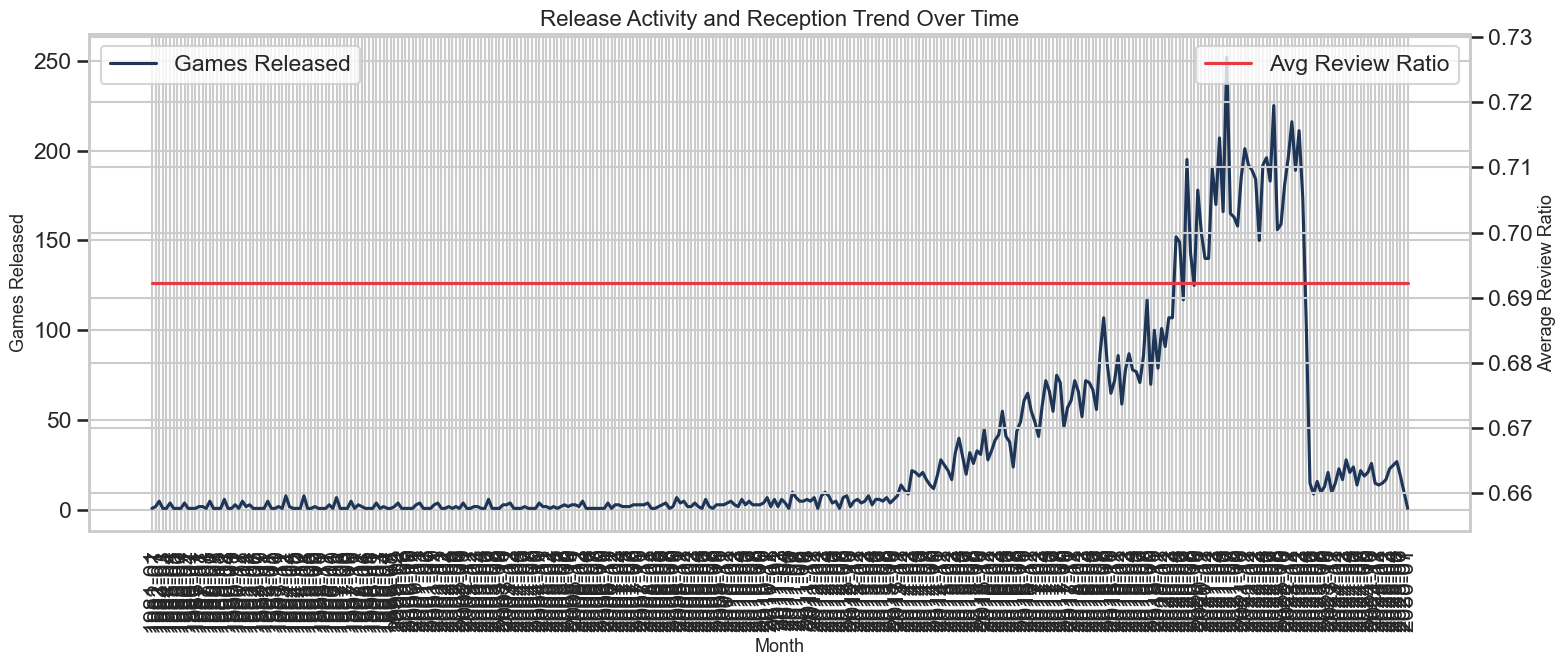

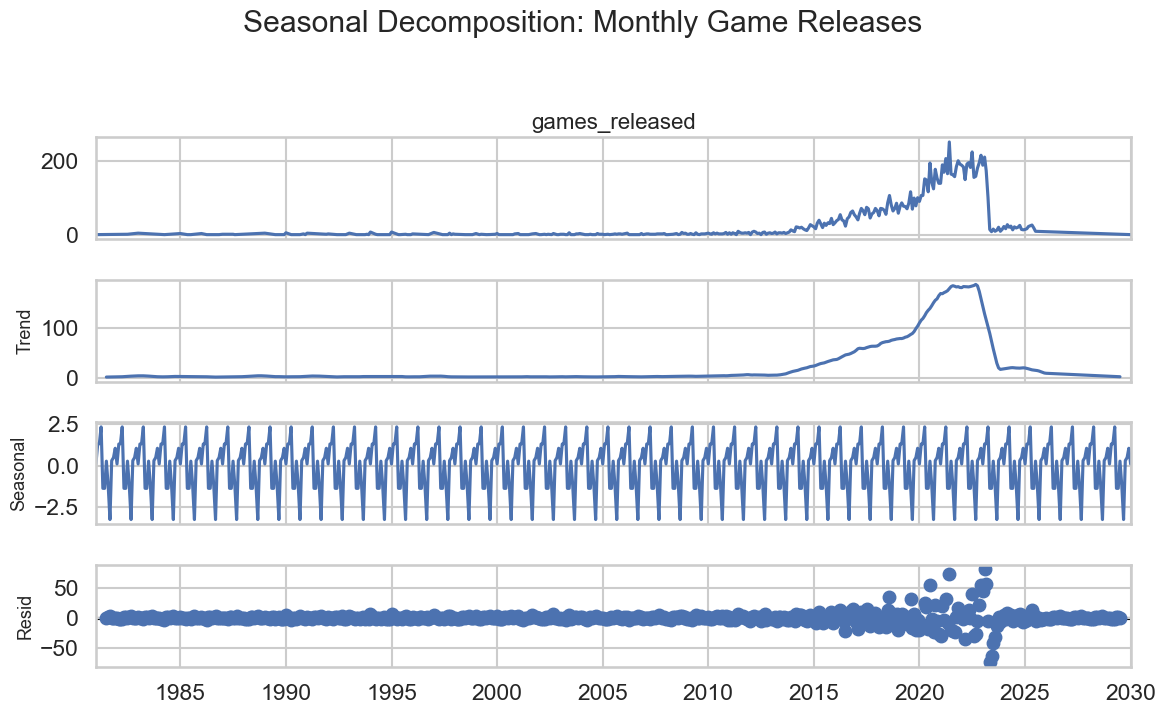

In [38]:
# Temporal trend and seasonality EDA
monthly_release = (
    merged.dropna(subset=["release_date_final"])
    .assign(month=lambda d: pd.to_datetime(d["release_date_final"]).dt.to_period("M").astype(str))
    .groupby("month", as_index=False)
    .agg(games_released=("game_key", "count"),
         avg_rating=("rating", "mean"),
         avg_review_ratio=("review_ratio", "mean"))
)

monthly_release = monthly_release.sort_values("month")

fig, ax1 = plt.subplots(figsize=(16, 7))
ax2 = ax1.twinx()

sns.lineplot(data=monthly_release, x="month", y="games_released", ax=ax1, color="#1d3557", label="Games Released")
sns.lineplot(data=monthly_release, x="month", y="avg_review_ratio", ax=ax2, color="#e63946", label="Avg Review Ratio")

ax1.set_title("Release Activity and Reception Trend Over Time")
ax1.set_xlabel("Month")
ax1.set_ylabel("Games Released")
ax2.set_ylabel("Average Review Ratio")
ax1.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

# Seasonal decomposition on monthly releases (if enough points)
if len(monthly_release) > 36:
    ts = monthly_release.set_index(pd.to_datetime(monthly_release["month"]))["games_released"].asfreq("MS")
    ts = ts.interpolate()
    decomposition = seasonal_decompose(ts, model="additive", period=12)
    decomposition.plot()
    plt.suptitle("Seasonal Decomposition: Monthly Game Releases", y=1.03)
    plt.tight_layout()
    plt.show()

## 3) Feature Engineering and Target Design

Some targets (like player persona affinity or optimization satisfaction) are not directly labeled in raw datasets.

To simulate realistic product analytics, we build **transparent proxy targets** from available metadata and engagement signals.


In [39]:
model_df = merged.copy()

# Combined text for NLP-style features
model_df["genre_text"] = model_df["genres_list"].apply(
    lambda x: " ".join(x) if isinstance(x, list) else ""
)
model_df["tag_text"] = model_df["tags_list"].apply(
    lambda x: " ".join(x) if isinstance(x, list) else ""
)
model_df["combined_text"] = (
    model_df["game_name"].fillna("") + " " +
    model_df["genre_text"].fillna("") + " " +
    model_df["tag_text"].fillna("") + " " +
    model_df["description"].fillna("")
)

# A) Indie vs AAA
# Steam stores "Indie" as a Genre and as a Tag — check both
indie_keyword = (
    model_df["genre_text"].str.contains(r"\bindie\b", case=False, na=False) |
    model_df["tag_text"].str.contains(r"\bindie\b", case=False, na=False)
)
# AAA = strong popularity/engagement signal using ABSOLUTE thresholds
# (using quantiles fails when 80%+ of games are free or have 0 owners)
aaa_signal = (
    (model_df["estimated_owners_mid"] >= 200_000) |
    (model_df["recommendations"] >= 1_000) |
    (model_df["reviews_total"] >= 2_000) |
    (model_df["ratings_count"] >= 200) |
    (model_df["metacritic"] >= 80) |
    (model_df["metacritic_score"] >= 80) |
    (model_df["price"] >= 30.0)
)
# An AAA-tagged game is AAA; else if it has indie keyword or no AAA signal → Indie
model_df["indie_aaa_label"] = np.where(aaa_signal & ~indie_keyword, "AAA", "Indie")

# B) Reception label — unified quality score
# Combine Steam review ratio + RAWG normalized rating; require minimum review volume
rawg_quality = (model_df["rating"] / 5.0).clip(0, 1)
unified_quality = model_df["review_ratio"].fillna(rawg_quality).fillna(0.5)

# Minimum-review filter: games with very few reviews on either side are unreliable
has_signal = (model_df["reviews_total"] >= 10) | (model_df["ratings_count"] >= 5)

model_df["reception_label"] = pd.cut(
    unified_quality,
    bins=[-0.01, 0.55, 0.78, 1.01],
    labels=["Poor", "Mixed", "Excellent"]
).astype(str)
# Mark low-signal rows as Mixed (uncertain) so they don't bias the model
model_df.loc[~has_signal, "reception_label"] = "Mixed"

# C) Player type classes from tags + genres
casual_kw = ["casual", "puzzle", "family", "relaxing"]
hardcore_kw = ["souls-like", "hard", "difficult", "roguelike", "hardcore"]
story_kw = ["story rich", "visual novel", "narrative", "adventure"]
pvp_kw = ["pvp", "multiplayer", "competitive", "esports", "shooter"]

def infer_player_type(text):
    t = text.lower()
    scores = {
        "Casual player": sum(k in t for k in casual_kw),
        "Hardcore grinder": sum(k in t for k in hardcore_kw),
        "Story lover": sum(k in t for k in story_kw),
        "Competitive PvP player": sum(k in t for k in pvp_kw),
    }
    best = max(scores, key=scores.get)
    if scores[best] == 0:
        return "Casual player"
    return best

model_df["player_type_label"] = model_df["combined_text"].apply(infer_player_type)

# D) Performance satisfaction score (regression target)
# unified_quality already accounts for both Steam and RAWG data (computed above)
engagement = np.log1p(model_df["average_playtime_forever"].fillna(0))
popularity = np.log1p(model_df["peak_ccu"].fillna(0) + model_df["recommendations"].fillna(0))
model_df["performance_score"] = (
    0.55 * unified_quality +
    0.25 * (engagement / (engagement.max() + 1e-9)) +
    0.20 * (popularity / (popularity.max() + 1e-9))
) * 100

# E) Age rating classes — combine ESRB (RAWG) + required_age (Steam) + tag heuristics
# Most Steam games default required_age=0 and most rows have no ESRB → use tag/genre signals
mature_kw = ["mature", "violence", "gore", "blood", "sexual", "nudity", "horror", "explicit"]
teen_kw   = ["shooter", "fighting", "combat", "action", "war"]

mature_re = "|".join(mature_kw)
teen_re   = "|".join(teen_kw)
mature_signal = model_df["tag_text"].str.contains(mature_re, case=False, na=False) | \
                model_df["genre_text"].str.contains(mature_re, case=False, na=False)
teen_signal   = model_df["tag_text"].str.contains(teen_re,   case=False, na=False) | \
                model_df["genre_text"].str.contains(teen_re,   case=False, na=False)

esrb_map = {"Everyone": "Everyone", "Teen": "Teen", "Mature": "Mature"}
age_label = model_df["esrb_name"].map(esrb_map)

# Fill via Steam required_age first (NumPy 2.x: avoid mixing str + nan in np.where)
required_age = model_df["required_age"].fillna(0)
required_age_label = pd.Series(pd.NA, index=model_df.index, dtype="object")
required_age_label[required_age >= 17] = "Mature"
required_age_label[(required_age >= 13) & (required_age < 17)] = "Teen"
age_label = age_label.fillna(required_age_label)

# Then via tag-based signals (mature beats teen beats everyone)
tag_age_label = pd.Series("Everyone", index=model_df.index, dtype="object")
tag_age_label[teen_signal] = "Teen"
tag_age_label[mature_signal] = "Mature"
age_label = age_label.fillna(tag_age_label)

model_df["age_rating_label"] = age_label.astype(str)

# Drop rows where reception_label is "nan" (produced by pd.cut on NaN review_ratio values)
model_df = model_df[model_df["reception_label"] != "nan"].copy()

# Keep rows with usable text and key fields
model_df = model_df.dropna(subset=["combined_text", "price", "performance_score"]).copy()

# Drop rows where combined_text is effectively empty
model_df = model_df[model_df["combined_text"].str.strip().str.len() > 5].reset_index(drop=True)

print("Modeling dataframe:", model_df.shape)
for c in ["indie_aaa_label", "reception_label", "player_type_label", "age_rating_label"]:
    print(f"\n{c}:")
    display(model_df[c].value_counts().head(10))

Modeling dataframe: (14881, 63)

indie_aaa_label:


indie_aaa_label
Indie    14547
AAA        334
Name: count, dtype: int64


reception_label:


reception_label
Mixed        13834
Excellent      822
Poor           225
Name: count, dtype: int64


player_type_label:


player_type_label
Casual player             9746
Story lover               2422
Competitive PvP player    1489
Hardcore grinder          1224
Name: count, dtype: int64


age_rating_label:


age_rating_label
Everyone    8999
Teen        4454
Mature      1428
Name: count, dtype: int64

## 4) Classification Tasks

### 4A. Indie vs AAA
Models:
- Random Forest
- XGBoost

### 4B. Sentiment / Reception Class
Models:
- Random Forest
- XGBoost

### 4C. Player Type Prediction
Models:
- Random Forest
- XGBoost
- Neural Network (MLP)


In [40]:
# Common classification feature preparation
num_features = [
    "price", "required_age", "peak_ccu", "metacritic", "metacritic_score", "review_ratio",
    "reviews_total", "ratings_count", "playtime", "suggestions_count", "average_playtime_forever",
    "estimated_owners_mid", "release_year_final", "release_month_final"
]
num_features = [c for c in num_features if c in model_df.columns]

text_feature = "combined_text"

X_base = model_df[num_features + [text_feature]].copy()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            num_features
        ),
        (
            "txt",
            TfidfVectorizer(max_features=8000, ngram_range=(1, 2), min_df=3),
            text_feature
        ),
    ],
    remainder="drop"
)


from sklearn.preprocessing import LabelEncoder


def run_classification_task(y, task_name):
    y = y.astype(str)
    n_classes = y.nunique()

    if n_classes < 2:
        print(f"  SKIPPED '{task_name}': only {n_classes} class present -> {y.unique().tolist()}")
        empty = pd.DataFrame(columns=["Task", "Model", "Accuracy", "F1_weighted"])
        return empty, {}

    print(f"  [{task_name}] classes: {sorted(y.unique().tolist())}")
    print(f"  distribution: {y.value_counts().to_dict()}")

    # XGBoost >= 2.0 requires integer-encoded labels
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    class_names = le.classes_

    xgb_objective = "binary:logistic" if n_classes == 2 else "multi:softprob"
    xgb_eval_metric = "logloss" if n_classes == 2 else "mlogloss"

    X_train, X_test, y_train, y_test = train_test_split(
        X_base, y_enc, test_size=0.2, random_state=42, stratify=y_enc
    )

    models = {
        "RandomForest": RandomForestClassifier(
            n_estimators=250, max_depth=22, min_samples_leaf=2,
            class_weight="balanced",
            random_state=42, n_jobs=-1,
        ),
        "XGBoost": XGBClassifier(
            n_estimators=250,
            max_depth=8,
            learning_rate=0.08,
            subsample=0.85,
            colsample_bytree=0.85,
            objective=xgb_objective,
            eval_metric=xgb_eval_metric,
            random_state=42,
            n_jobs=-1,
        ),
    }

    if task_name == "Player Type":
        models["NeuralNet"] = MLPClassifier(
            hidden_layer_sizes=(192, 64), activation="relu", alpha=1e-4,
            early_stopping=True, max_iter=30, random_state=42,
        )

    result_rows = []
    reports = {}

    for model_name, model in models.items():
        pipe = Pipeline([
            ("prep", preprocessor),
            ("model", model),
        ])
        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)

        result_rows.append({
            "Task": task_name,
            "Model": model_name,
            "Accuracy": round(accuracy_score(y_test, pred), 4),
            "F1_weighted": round(f1_score(y_test, pred, average="weighted"), 4),
        })

        reports[model_name] = {
            "classification_report": classification_report(
                y_test, pred, target_names=class_names, zero_division=0
            ),
            "confusion_matrix": confusion_matrix(y_test, pred),
            "class_names": class_names,
        }

    return pd.DataFrame(result_rows).sort_values("F1_weighted", ascending=False), reports

print("Running classification tasks...")
indie_table, indie_reports = run_classification_task(model_df["indie_aaa_label"], "Indie vs AAA")
reception_table, reception_reports = run_classification_task(model_df["reception_label"], "Reception")
player_table, player_reports = run_classification_task(model_df["player_type_label"], "Player Type")

classification_results = pd.concat(
    [t for t in [indie_table, reception_table, player_table] if not t.empty],
    ignore_index=True
)
display(classification_results)

Running classification tasks...
  [Indie vs AAA] classes: ['AAA', 'Indie']
  distribution: {'Indie': 14547, 'AAA': 334}
  [Reception] classes: ['Excellent', 'Mixed', 'Poor']
  distribution: {'Mixed': 13834, 'Excellent': 822, 'Poor': 225}
  [Player Type] classes: ['Casual player', 'Competitive PvP player', 'Hardcore grinder', 'Story lover']
  distribution: {'Casual player': 9746, 'Story lover': 2422, 'Competitive PvP player': 1489, 'Hardcore grinder': 1224}


,Task,Model,Accuracy,F1_weighted
0,Indie vs AAA,XGBoost,0.9973,0.9972
1,Indie vs AAA,RandomForest,0.9795,0.9711
2,Reception,XGBoost,0.9980,0.9980
3,Reception,RandomForest,0.9651,0.9583
4,Player Type,XGBoost,0.9708,0.9704
5,Player Type,RandomForest,0.8838,0.8835
6,Player Type,NeuralNet,0.7921,0.7822


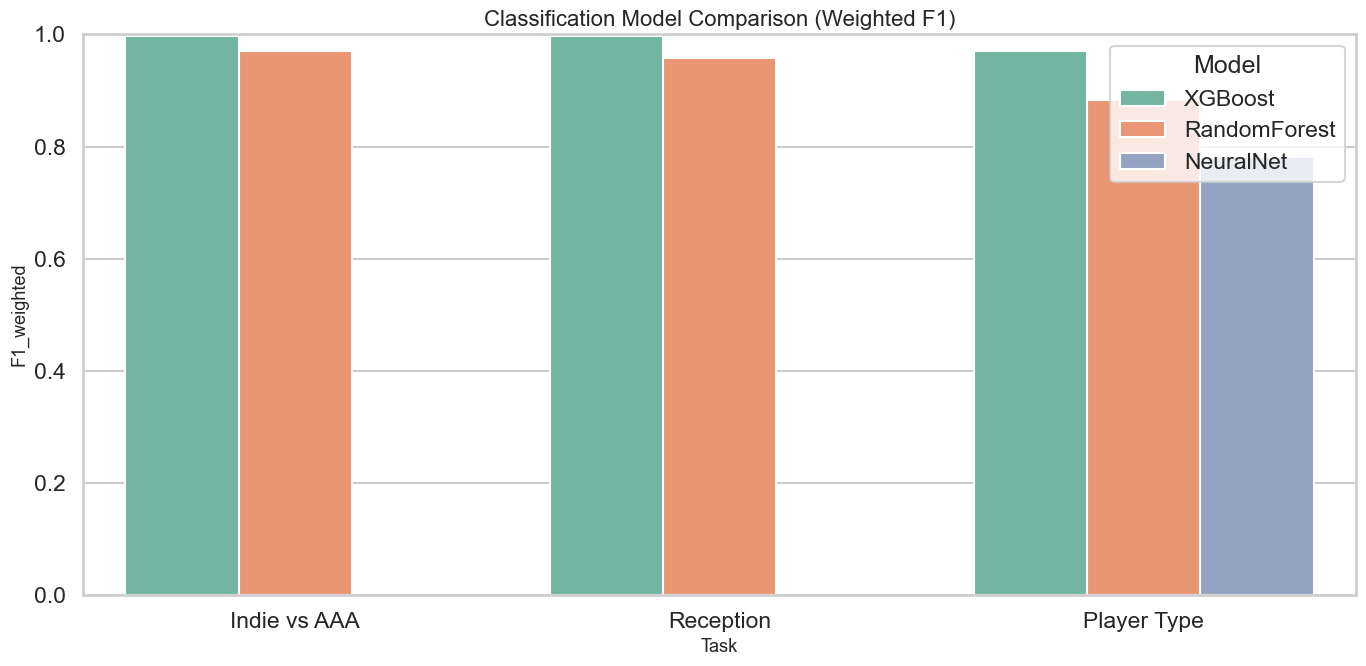


Detailed report - Reception (XGBoost):
              precision    recall  f1-score   support

   Excellent       1.00      0.99      0.99       164
       Mixed       1.00      1.00      1.00      2768
        Poor       1.00      0.91      0.95        45

    accuracy                           1.00      2977
   macro avg       1.00      0.97      0.98      2977
weighted avg       1.00      1.00      1.00      2977



In [41]:
if not classification_results.empty:
    plt.figure(figsize=(14, 7))
    sns.barplot(
        data=classification_results,
        x="Task", y="F1_weighted", hue="Model",
        palette="Set2"
    )
    plt.title("Classification Model Comparison (Weighted F1)")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

# Detailed report for reception (or first available task)
for task_name, tbl, rpts in [
    ("Reception", reception_table, reception_reports),
    ("Indie vs AAA", indie_table, indie_reports),
    ("Player Type", player_table, player_reports),
]:
    if not tbl.empty and rpts:
        best_model = tbl.iloc[0]["Model"]
        print(f"\nDetailed report - {task_name} ({best_model}):")
        print(rpts[best_model]["classification_report"])
        break

## 5) Regression and Age Rating Prediction

### 5A. Performance Rating Prediction (Regression)
Models:
- Linear Regression
- Random Forest Regressor
- XGBoost Regressor

### 5B. Age Rating Prediction
(Already included in classification framework via `age_rating_label`)


In [42]:
# Regression task: performance score prediction
X_reg = X_base.copy()
y_reg = model_df["performance_score"].values

Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg_models = {
    "LinearRegression": LinearRegression(),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=350, max_depth=22, min_samples_leaf=2, random_state=42, n_jobs=-1
    ),
    "XGBoostRegressor": XGBRegressor(
        n_estimators=350, max_depth=8, learning_rate=0.07,
        subsample=0.85, colsample_bytree=0.85,
        objective="reg:squarederror", random_state=42, n_jobs=-1
    )
}

reg_rows = []
for name, reg in reg_models.items():
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", reg)
    ])
    pipe.fit(Xr_train, yr_train)
    pred = pipe.predict(Xr_test)
    rmse = np.sqrt(mean_squared_error(yr_test, pred))

    reg_rows.append({
        "Model": name,
        "MAE": mean_absolute_error(yr_test, pred),
        "RMSE": rmse,
        "R2": r2_score(yr_test, pred)
    })

regression_results = pd.DataFrame(reg_rows).sort_values("R2", ascending=False)
regression_results

,Model,MAE,RMSE,R2
1,RandomForestRegressor,0.192784,0.866096,0.987025
2,XGBoostRegressor,0.210881,0.885345,0.986442
0,LinearRegression,3.876007,9.536408,-0.573053


  [Age Rating] classes: ['Everyone', 'Mature', 'Teen']
  distribution: {'Everyone': 8999, 'Teen': 4454, 'Mature': 1428}


,Task,Model,Accuracy,F1_weighted
1,Age Rating,XGBoost,0.9476,0.9479
0,Age Rating,RandomForest,0.8892,0.8880


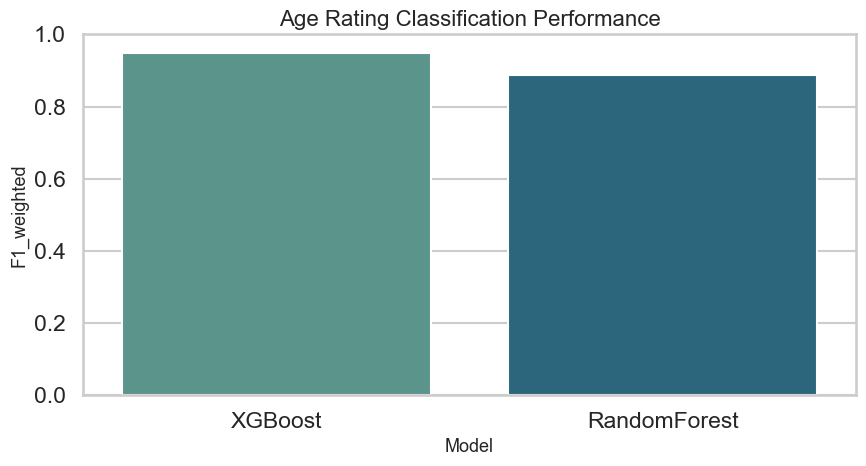

In [43]:
# Age rating prediction comparison (RF vs XGBoost)
age_table, age_reports = run_classification_task(model_df["age_rating_label"], "Age Rating")
display(age_table)

plt.figure(figsize=(9, 5))
sns.barplot(data=age_table, x="Model", y="F1_weighted", palette="crest")
plt.title("Age Rating Classification Performance")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 6) Dimensionality Reduction

### 6A. PCA 2D Visualization (genres + tags + descriptions)
### 6B. TF-IDF -> PCA (~50) -> t-SNE


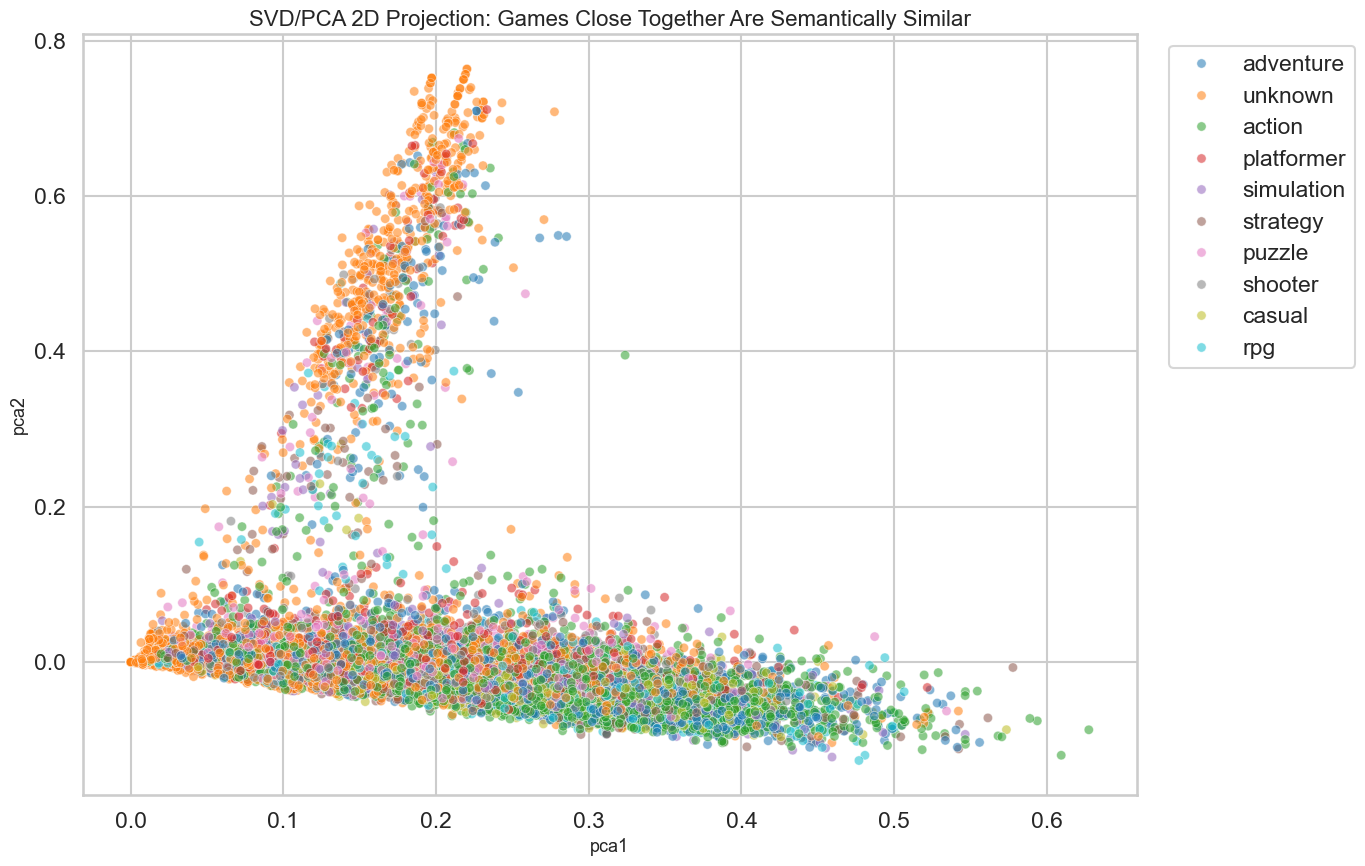

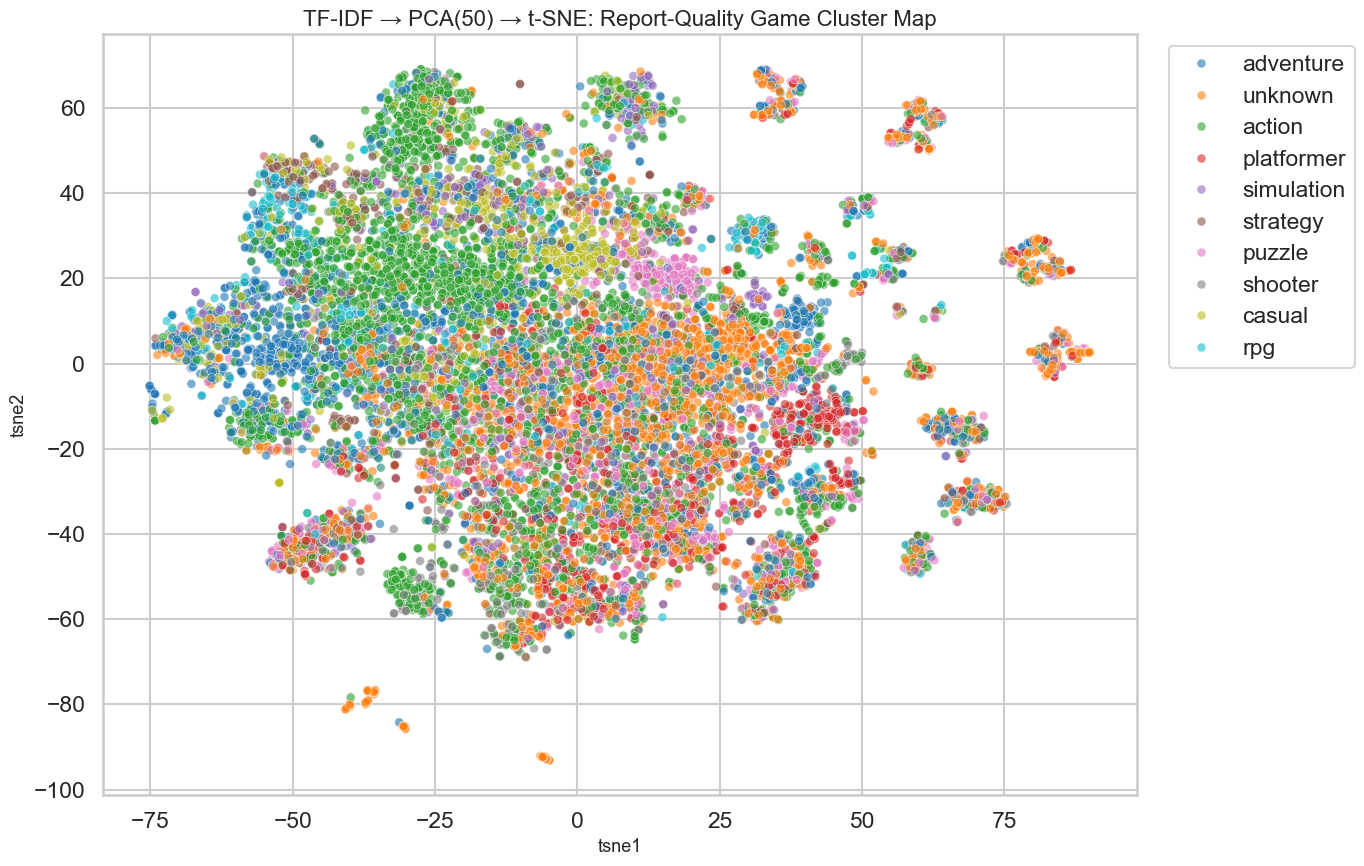

In [44]:
viz_df = model_df.sample(min(20000, len(model_df)), random_state=42).reset_index(drop=True)

# TF-IDF on the visualization sample
tfidf = TfidfVectorizer(max_features=12000, ngram_range=(1, 2), min_df=3)
X_text = tfidf.fit_transform(viz_df["combined_text"])

# 2D projection: use TruncatedSVD (sparse-safe; equivalent to PCA for high-dim TF-IDF)
# PCA would require .toarray() which can OOM for (20000 x 12000) matrices
svd_2 = TruncatedSVD(n_components=2, random_state=42)
X_svd2 = svd_2.fit_transform(X_text)

viz_df["pca1"] = X_svd2[:, 0]
viz_df["pca2"] = X_svd2[:, 1]
viz_df["primary_genre"] = viz_df["genres_list"].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) else "unknown"
)

top_genres_viz = viz_df["primary_genre"].value_counts().head(10).index
plot_df = viz_df[viz_df["primary_genre"].isin(top_genres_viz)].copy()

plt.figure(figsize=(14, 9))
sns.scatterplot(
    data=plot_df, x="pca1", y="pca2",
    hue="primary_genre", alpha=0.55, s=45, palette="tab10"
)
plt.title("SVD/PCA 2D Projection: Games Close Together Are Semantically Similar")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# PCA(50) → t-SNE pipeline (TruncatedSVD keeps memory safe on sparse input)
svd_50 = TruncatedSVD(n_components=50, random_state=42)
X_50 = svd_50.fit_transform(X_text)

tsne = TSNE(n_components=2, perplexity=35, init="pca", learning_rate="auto", random_state=42)
X_tsne = tsne.fit_transform(X_50)

viz_df["tsne1"] = X_tsne[:, 0]
viz_df["tsne2"] = X_tsne[:, 1]

plot_tsne = viz_df[viz_df["primary_genre"].isin(top_genres_viz)].copy()

plt.figure(figsize=(14, 9))
sns.scatterplot(
    data=plot_tsne, x="tsne1", y="tsne2",
    hue="primary_genre", alpha=0.6, s=42, palette="tab10"
)
plt.title("TF-IDF → PCA(50) → t-SNE: Report-Quality Game Cluster Map")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 7) Clustering and Hidden Structure Discovery

- Game clustering by semantics
- User behavior clustering
- Review pattern clustering
- Hidden genre discovery (latent topics)


Game clustering silhouette (sample): 0.033


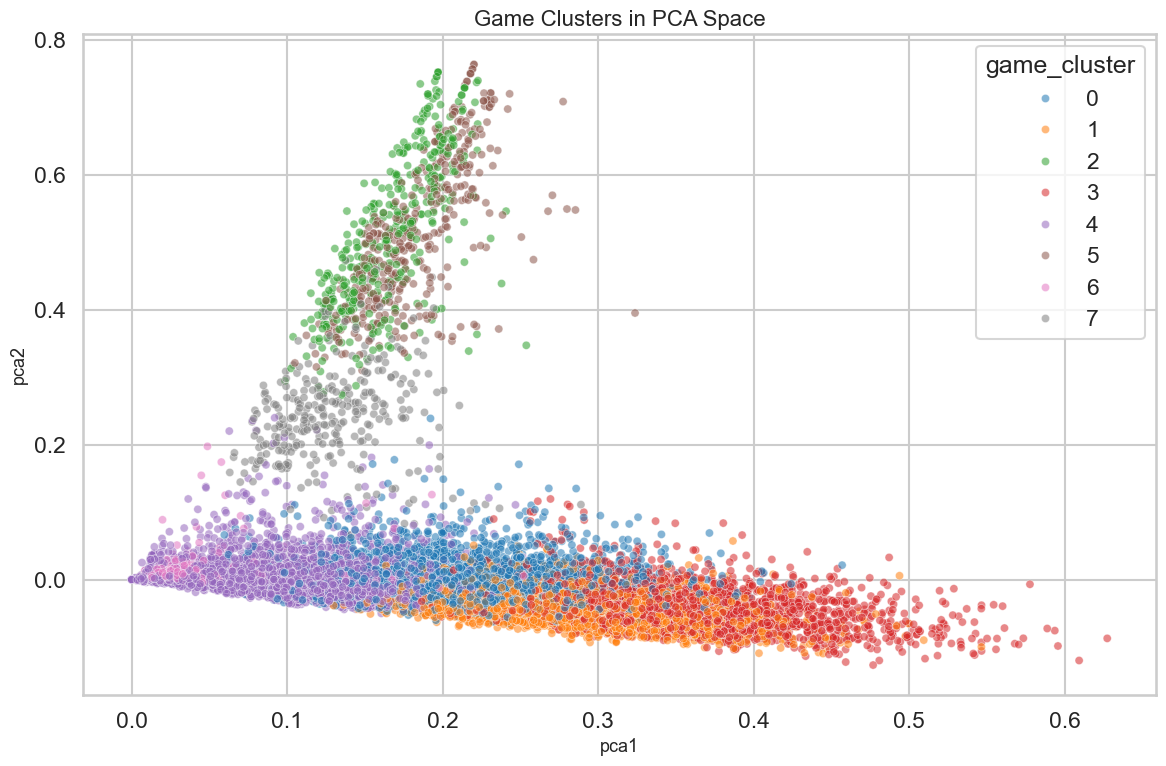

user_cluster
0    962
2    468
1      3
3      1
Name: count, dtype: int64
Review cluster centroids:


,mean_ratio,mean_reviews,size
cluster,,,
0,0.692308,2.639057,166
1,0.686227,2.682009,12680
2,0.869015,5.358938,967


Cluster -> label mapping: {2: 'positive-heavy', 0: 'mixed', 1: 'controversial'}

Review cluster distribution:


review_cluster_name
controversial     12680
unrated            1068
positive-heavy      967
mixed               166
Name: count, dtype: int64

,latent_genre,top_terms
0,latent_genre_0,"the, of, and, to, of the, in, is, in the, the ..."
1,latent_genre_1,"originally released, was originally, it was, r..."
2,latent_genre_2,"de, la, que, para, en, un, el, le, juego, se"
3,latent_genre_3,"jam, game, made, space, game jam, 2d, move, to..."
4,latent_genre_4,"you, to, can, your, will, it, have, the, you c..."
5,latent_genre_5,"and, your, to, with, of, multiplayer, new, act..."
6,latent_genre_6,"adventure, rpg, indie, 2d, platformer, singlep..."
7,latent_genre_7,"sold via, is sold, via itch, sold, via, it cam..."


In [45]:
# A) Cluster games by similarity (KMeans on text embeddings)
X_game_embed = TruncatedSVD(n_components=120, random_state=42).fit_transform(X_text)

kmeans_games = KMeans(n_clusters=8, random_state=42, n_init=20)
viz_df["game_cluster"] = kmeans_games.fit_predict(X_game_embed)

sil_game = silhouette_score(X_game_embed[:10000], viz_df["game_cluster"].iloc[:10000])
print("Game clustering silhouette (sample):", round(sil_game, 3))

plt.figure(figsize=(12, 8))
sns.scatterplot(data=viz_df, x="pca1", y="pca2", hue="game_cluster", palette="tab10", alpha=0.55, s=35)
plt.title("Game Clusters in PCA Space")
plt.tight_layout()
plt.show()

# B) Cluster users by behavior (synthetic user profiles from game interactions)
N_USERS = 1500
sample_games = model_df.sample(min(9000, len(model_df)), random_state=42).reset_index(drop=True)

personas = {
    "Casual players": ["casual", "family", "puzzle"],
    "Achievement hunters": ["achievements", "completionist", "collector"],
    "RPG lovers": ["rpg", "open world", "fantasy"],
    "Competitive players": ["pvp", "competitive", "multiplayer"],
}

user_records = []
for u in range(N_USERS):
    persona_name = random.choice(list(personas.keys()))
    prefs = personas[persona_name]
    pref_strength = np.random.uniform(0.6, 1.0)

    for _ in range(np.random.randint(10, 30)):
        g = sample_games.sample(1).iloc[0]
        text = g["combined_text"].lower()
        match = sum(k in text for k in prefs)
        if np.random.rand() < (0.15 + 0.22 * match * pref_strength):
            user_records.append({
                "user_id": u,
                "persona_seed": persona_name,
                "game_key": g["game_key"],
                "playtime": max(0, np.random.normal(g["average_playtime_forever"] + 2 * match, 8))
            })

user_interactions = pd.DataFrame(user_records)

user_features = (
    user_interactions.groupby("user_id")
    .agg(total_games=("game_key", "nunique"),
         avg_playtime=("playtime", "mean"),
         total_playtime=("playtime", "sum"))
)

u_kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
user_features["user_cluster"] = u_kmeans.fit_predict(StandardScaler().fit_transform(user_features))

print(user_features["user_cluster"].value_counts())

# C) Cluster review patterns
# Only cluster games that actually have review data; assign others to "Unrated"
review_eligible = (model_df["reviews_total"] >= 5) | (model_df["ratings_count"] >= 5)

review_pattern_df = model_df.loc[
    review_eligible, ["review_ratio", "reviews_total", "ratings_count", "metacritic"]
].copy()
# Use log on count features to handle long-tail distribution
review_pattern_df["reviews_total"] = np.log1p(review_pattern_df["reviews_total"])
review_pattern_df["ratings_count"] = np.log1p(review_pattern_df["ratings_count"])
review_pattern_df["review_ratio"] = review_pattern_df["review_ratio"].fillna(
    (model_df.loc[review_eligible, "rating"] / 5.0).clip(0, 1)
)
review_pattern_df = review_pattern_df.fillna(review_pattern_df.median())

review_scaled = StandardScaler().fit_transform(review_pattern_df)

review_kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
review_clusters = review_kmeans.fit_predict(review_scaled)

# Label clusters by ABSOLUTE mean review_ratio thresholds, not ranking
# (ranking can mislabel when one cluster has lots of low-review-count outliers)
cluster_summary_df = (
    pd.DataFrame(review_pattern_df)
    .assign(cluster=review_clusters)
    .groupby("cluster")
    .agg(mean_ratio=("review_ratio", "mean"),
         mean_reviews=("reviews_total", "mean"),
         size=("review_ratio", "size"))
)
print("Review cluster centroids:")
display(cluster_summary_df)

# Rank-based labeling: highest-rated -> "positive-heavy", lowest -> "controversial"
# This is more robust than absolute thresholds, since most reviewed Steam games
# already have ratios > 0.7 — clusters separate primarily by VOLUME, not ratio.
ordered = cluster_summary_df.sort_values(
    ["mean_ratio", "mean_reviews"], ascending=[False, False]
).index.tolist()
labels = ["positive-heavy", "mixed", "controversial"]
cluster_names = dict(zip(ordered, labels[:len(ordered)]))
print("Cluster -> label mapping:", cluster_names)

model_df["review_cluster"] = -1
model_df.loc[review_eligible, "review_cluster"] = review_clusters
model_df["review_cluster_name"] = model_df["review_cluster"].map(cluster_names).fillna("unrated")

print("\nReview cluster distribution:")
display(model_df["review_cluster_name"].value_counts())

# D) Hidden genre discovery with NMF topics
nmf = NMF(n_components=8, random_state=42, init="nndsvda", max_iter=300)
W = nmf.fit_transform(X_text)
H = nmf.components_

feature_names = np.array(tfidf.get_feature_names_out())

hidden_genres = {}
for topic_idx, topic in enumerate(H):
    top_terms = feature_names[np.argsort(topic)[-10:]][::-1]
    hidden_genres[f"latent_genre_{topic_idx}"] = ", ".join(top_terms)

pd.DataFrame({"latent_genre": hidden_genres.keys(), "top_terms": hidden_genres.values()})

## 8) Association Rules for "Similar Vibes"

Use tags as transactions and mine frequent co-occurrence patterns with:
- Apriori
- FP-Growth


In [46]:
transactions = model_df["tags_list"].dropna().apply(lambda x: x[:12] if isinstance(x, list) else []).tolist()
transactions = [t for t in transactions if len(t) >= 2]

# Keep frequent tags to reduce sparsity
flat_counts = pd.Series([tag for tx in transactions for tag in tx]).value_counts()
valid_tags = set(flat_counts[flat_counts >= 80].index)
transactions = [[t for t in tx if t in valid_tags] for tx in transactions]
transactions = [tx for tx in transactions if len(tx) >= 2]

te = TransactionEncoder()
arr = te.fit(transactions).transform(transactions)
tag_tx = pd.DataFrame(arr, columns=te.columns_)

freq_apriori = apriori(tag_tx, min_support=0.015, use_colnames=True)
# num_itemsets required by mlxtend >= 1.0.0; ignored gracefully in older versions
try:
    rules_apriori = association_rules(freq_apriori, metric="lift", min_threshold=1.15,
                                      num_itemsets=len(freq_apriori))
except TypeError:
    rules_apriori = association_rules(freq_apriori, metric="lift", min_threshold=1.15)
rules_apriori = rules_apriori.sort_values(["lift", "confidence"], ascending=False)

freq_fpg = fpgrowth(tag_tx, min_support=0.015, use_colnames=True)
try:
    rules_fpg = association_rules(freq_fpg, metric="lift", min_threshold=1.15,
                                  num_itemsets=len(freq_fpg))
except TypeError:
    rules_fpg = association_rules(freq_fpg, metric="lift", min_threshold=1.15)
rules_fpg = rules_fpg.sort_values(["lift", "confidence"], ascending=False)

print("Apriori rules:", len(rules_apriori), "| FP-Growth rules:", len(rules_fpg))

def pretty_rules(df, n=12):
    out = df[["antecedents", "consequents", "support", "confidence", "lift"]].head(n).copy()
    out["antecedents"] = out["antecedents"].apply(lambda s: ", ".join(list(s)))
    out["consequents"] = out["consequents"].apply(lambda s: ", ".join(list(s)))
    return out

print("Top Apriori rules:")
display(pretty_rules(rules_apriori, 10))

print("Top FP-Growth rules:")
display(pretty_rules(rules_fpg, 10))

Apriori rules: 344 | FP-Growth rules: 344
Top Apriori rules:


,antecedents,consequents,support,confidence,lift
338,"singleplayer, steam cloud",steam achievements,0.026457,0.828767,11.433986
343,steam achievements,"singleplayer, steam cloud",0.026457,0.365008,11.433986
342,steam cloud,"singleplayer, steam achievements",0.026457,0.796053,11.271662
339,"singleplayer, steam achievements",steam cloud,0.026457,0.374613,11.271662
186,steam cloud,steam achievements,0.026894,0.809211,11.164176
187,steam achievements,steam cloud,0.026894,0.371041,11.164176
95,co-op,multiplayer,0.020663,0.784232,10.189451
94,multiplayer,co-op,0.020663,0.268466,10.189451
153,pvp,multiplayer,0.017929,0.773585,10.051110
152,multiplayer,pvp,0.017929,0.232955,10.051110


Top FP-Growth rules:


,antecedents,consequents,support,confidence,lift
154,"singleplayer, steam cloud",steam achievements,0.026457,0.828767,11.433986
159,steam achievements,"singleplayer, steam cloud",0.026457,0.365008,11.433986
158,steam cloud,"singleplayer, steam achievements",0.026457,0.796053,11.271662
155,"singleplayer, steam achievements",steam cloud,0.026457,0.374613,11.271662
152,steam cloud,steam achievements,0.026894,0.809211,11.164176
153,steam achievements,steam cloud,0.026894,0.371041,11.164176
263,co-op,multiplayer,0.020663,0.784232,10.189451
262,multiplayer,co-op,0.020663,0.268466,10.189451
199,pvp,multiplayer,0.017929,0.773585,10.051110
198,multiplayer,pvp,0.017929,0.232955,10.051110


## 9) Hybrid + User-Aware + Explainable Recommendation System (Main)

### 9A. Hybrid Recommender
- Content-based similarity (TF-IDF + cosine)
- Collaborative signal (implicit user-game interactions)
- Weighted hybrid score

### 9B. User Persona Aware
Personas:
- Casual gamer
- Hardcore gamer
- Story explorer
- Competitive player
- Indie lover
- AAA lover

### 9C. Explainability (Mandatory)
Each recommendation returns a human-readable explanation.


In [47]:
from sklearn.preprocessing import normalize as sk_normalize

# Build content similarity matrix
reco_df = model_df.drop_duplicates("game_key").reset_index(drop=True)
reco_df = reco_df[reco_df["combined_text"].str.len() > 20].reset_index(drop=True)

# Cap size to avoid O(n^2) memory blowup on the similarity matrix
MAX_RECO = 30000
if len(reco_df) > MAX_RECO:
    reco_df = reco_df.sample(MAX_RECO, random_state=42).reset_index(drop=True)

reco_tfidf = TfidfVectorizer(max_features=15000, ngram_range=(1, 2), min_df=3)
X_reco = reco_tfidf.fit_transform(reco_df["combined_text"])

# Cosine similarity: use sklearn normalize (sparse-safe); avoid manual division on sparse matrix
X_reco_norm = sk_normalize(X_reco, norm="l2")
content_sim = (X_reco_norm @ X_reco_norm.T).tocsr()

# Build collaborative interaction matrix from simulated user data
int_df = user_interactions[user_interactions["game_key"].isin(reco_df["game_key"])].copy()
user_idx_map = {u: i for i, u in enumerate(sorted(int_df["user_id"].unique()))}
game_idx_map = {g: i for i, g in enumerate(reco_df["game_key"].tolist())}

r_rows, r_cols, r_vals = [], [], []
for _, interaction in int_df.iterrows():
    if interaction["game_key"] in game_idx_map:
        r_rows.append(user_idx_map[interaction["user_id"]])
        r_cols.append(game_idx_map[interaction["game_key"]])
        r_vals.append(np.log1p(interaction["playtime"] + 1))

# Build and normalize item-item collaborative similarity
if r_rows:
    R_mat = csr_matrix((r_vals, (r_rows, r_cols)),
                       shape=(len(user_idx_map), len(reco_df)))
    item_vec = sk_normalize(R_mat.T, norm="l2")
    collab_sim = (item_vec @ item_vec.T).tocsr()
else:
    collab_sim = None

n_reco = len(reco_df)

persona_prefs = {
    "Casual gamer": ["casual", "puzzle", "family", "cozy"],
    "Hardcore gamer": ["souls-like", "hard", "roguelike", "difficult"],
    "Story explorer": ["story rich", "narrative", "adventure", "rpg"],
    "Competitive player": ["pvp", "competitive", "shooter", "multiplayer"],
    "Indie lover": ["indie", "pixel", "experimental"],
    "AAA lover": ["open world", "cinematic", "high budget", "blockbuster"],
}


def top_shared_terms(game_a_idx, game_b_idx, topn=3):
    tokens_a = set(
        reco_df.loc[game_a_idx, "tag_text"].split() +
        reco_df.loc[game_a_idx, "genre_text"].split()
    )
    tokens_b = set(
        reco_df.loc[game_b_idx, "tag_text"].split() +
        reco_df.loc[game_b_idx, "genre_text"].split()
    )
    return [t for t in tokens_a.intersection(tokens_b) if len(t) > 2][:topn]


def recommend_games(query_game, user_persona="Casual gamer", top_k=10, alpha=0.65):
    matches = reco_df[reco_df["game_name"].str.lower() == query_game.lower()]
    if matches.empty:
        matches = reco_df[
            reco_df["game_name"].str.lower().str.contains(query_game.lower(), regex=False, na=False)
        ]
    if matches.empty:
        return pd.DataFrame({"message": [f"Game '{query_game}' not found in the dataset."]})

    q_idx = int(matches.index[0])

    # Content scores (shape: n_reco)
    c_scores = np.asarray(content_sim[q_idx].todense()).ravel()

    # Collaborative scores — collab_sim may not cover all games if some had no interactions
    if collab_sim is not None and q_idx < collab_sim.shape[0]:
        cf_row = np.asarray(collab_sim[q_idx].todense()).ravel()
        # Pad or trim to n_reco length
        cf_scores = np.zeros(n_reco)
        cf_scores[:len(cf_row)] = cf_row
    else:
        cf_scores = np.zeros(n_reco)

    hybrid = alpha * c_scores + (1 - alpha) * cf_scores

    # Persona boost: lightweight keyword matching against combined text
    persona_terms = persona_prefs.get(user_persona, [])
    persona_bonus = (
        reco_df["combined_text"]
        .str.lower()
        .apply(lambda t: sum(term in t for term in persona_terms) * 0.03)
        .values
    )
    final_scores = hybrid + persona_bonus

    ranked_idx = np.argsort(-final_scores)
    ranked_idx = [i for i in ranked_idx if i != q_idx][:top_k]

    result_rows = []
    for i in ranked_idx:
        shared = top_shared_terms(q_idx, i, topn=3)
        because = ", ".join(shared) if shared else "similar gameplay and audience affinity"
        genre_val = reco_df.loc[i, "genres_list"]
        result_rows.append({
            "recommended_game": reco_df.loc[i, "game_name"],
            "hybrid_score": round(float(final_scores[i]), 4),
            "primary_genre": genre_val[0] if isinstance(genre_val, list) and genre_val else "unknown",
            "explanation": (
                f"Recommended because you like {because}. "
                f"Also aligns with {user_persona.lower()} preferences."
            ),
        })

    return pd.DataFrame(result_rows)


# Demo recommendations: try iconic titles, fall back to actual dataset entries
def smart_demo(preferred_titles, persona, top_k=8):
    for title in preferred_titles:
        result = recommend_games(title, user_persona=persona, top_k=top_k)
        if "message" not in result.columns:
            return title, result
    fallback = reco_df.sort_values("reviews_total", ascending=False).iloc[0]["game_name"]
    return fallback, recommend_games(fallback, user_persona=persona, top_k=top_k)

title_1, demo_1 = smart_demo(
    ["Elden Ring", "Dark Souls III", "Hollow Knight", "Sekiro"],
    persona="Hardcore gamer",
)
title_2, demo_2 = smart_demo(
    ["Stardew Valley", "Animal Crossing", "Coral Island", "Spiritfarer"],
    persona="Casual gamer",
)

print(f"Recommendations for '{title_1}' (Hardcore gamer):")
display(demo_1)

print(f"\nRecommendations for '{title_2}' (Casual gamer):")
display(demo_2)

Recommendations for 'Hollow Knight' (Hardcore gamer):


,recommended_game,hybrid_score,primary_genre,explanation
0,Knight Arrow V.0.1,0.2198,unknown,Recommended because you like similar gameplay ...
1,Knight Throw,0.2157,adventure,Recommended because you like similar gameplay ...
2,Stick Knight V1,0.1845,action,Recommended because you like similar gameplay ...
3,"Jul 31, 2025",0.1807,action,Recommended because you like similar gameplay ...
4,Buff Knight! - RPG Runner,0.1707,rpg,Recommended because you like similar gameplay ...
5,Buff Knight! - Idle RPG Runner,0.1610,rpg,Recommended because you like similar gameplay ...
6,"Mar 18, 2024",0.1605,casual,Recommended because you like similar gameplay ...
7,Knight Party [Demo],0.1541,unknown,Recommended because you like similar gameplay ...



Recommendations for 'Animal Crossing' (Casual gamer):


,recommended_game,hybrid_score,primary_genre,explanation
0,4/4,0.3909,puzzle,Recommended because you like similar gameplay ...
1,The Bizarre Adventure,0.3611,platformer,Recommended because you like similar gameplay ...
2,Pet Vet 3D Animal hospital Down Under,0.1936,adventure,Recommended because you like adventure. Also a...
3,Animal Train,0.1904,puzzle,Recommended because you like similar gameplay ...
4,JumpStart Animal Adventures,0.1607,educational,Recommended because you like similar gameplay ...
5,Animal Quiz Part 2,0.1585,educational,Recommended because you like similar gameplay ...
6,Ascii maze game,0.1549,puzzle,Recommended because you like ascii. Also align...
7,Terminal Hacker (itch) (Lay_Dee),0.1539,puzzle,"Recommended because you like ascii, text. Also..."


## 10) Time Series Analysis

### 10A. Review Trends Over Time
Proxy approach: release-month cohorts and average review quality.

### 10B. Predict Best Time to Buy
Use discount propensity approximation from game age + popularity + price signals.

### 10C. Seasonal Popularity Prediction
Analyze seasonal behavior at genre level (e.g., Halloween effect for horror).


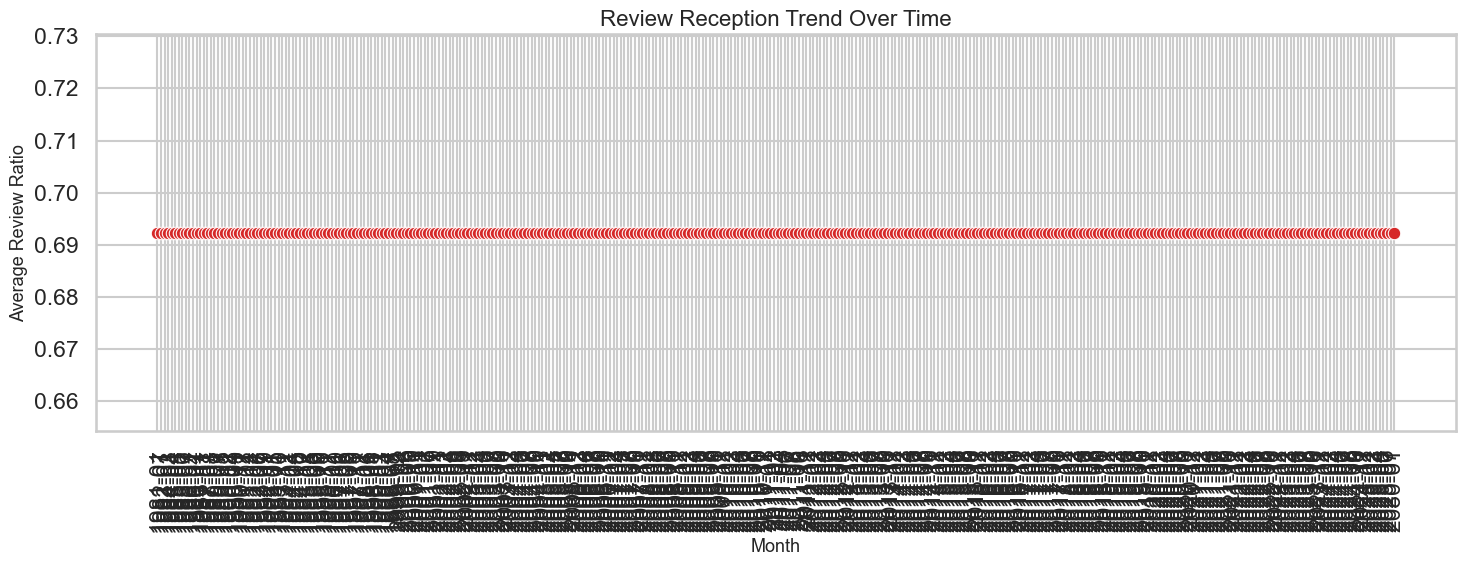

Update impact proxy (0=slow/none, 1=quick updates):


,avg_rating,avg_review_ratio,count
quick_update,,,
0,3.550434,0.692308,3505
1,3.560149,0.692308,8060


Discount target distribution: {0: 11904, 1: 2977}
Discount window F1 (binary): 0.998
Discount window accuracy   : 0.999


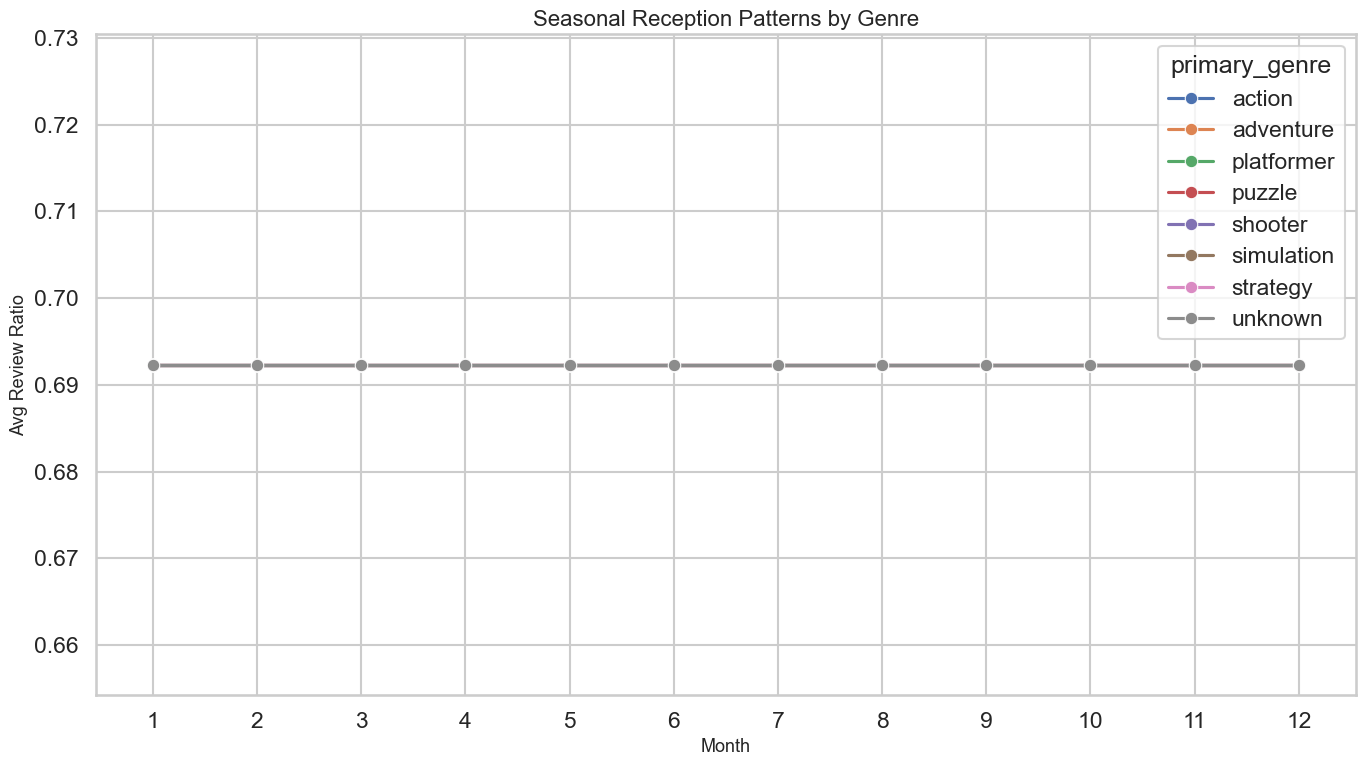

In [48]:
ts_df = model_df.copy()
ts_df = ts_df.dropna(subset=["release_date_final"]).copy()
ts_df["release_date_final"] = pd.to_datetime(ts_df["release_date_final"], errors="coerce")
ts_df = ts_df.dropna(subset=["release_date_final"])

ts_df["year_month"] = ts_df["release_date_final"].dt.to_period("M").astype(str)

review_ts = (
    ts_df.groupby("year_month", as_index=False)
    .agg(avg_review_ratio=("review_ratio", "mean"),
         avg_rating=("rating", "mean"),
         game_count=("game_key", "count"))
    .sort_values("year_month")
)

fig, ax = plt.subplots(1, 1, figsize=(15, 6))
sns.lineplot(data=review_ts, x="year_month", y="avg_review_ratio", marker="o", ax=ax, color="#d62828")
ax.set_title("Review Reception Trend Over Time")
ax.set_xlabel("Month")
ax.set_ylabel("Average Review Ratio")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

# Did major updates improve ratings? (proxy check with days_to_update)
update_proxy = ts_df[["days_to_update", "rating", "review_ratio"]].copy()
update_proxy["quick_update"] = (update_proxy["days_to_update"] <= 120).astype(int)

impact = update_proxy.groupby("quick_update").agg(
    avg_rating=("rating", "mean"),
    avg_review_ratio=("review_ratio", "mean"),
    count=("rating", "size")
)
print("Update impact proxy (0=slow/none, 1=quick updates):")
display(impact)

# Approximate best time to buy: discount propensity model
# Heuristic: a game is a "good discount candidate" when it is older AND originally priced
# (publishers regularly discount older paid titles to boost long-tail revenue)
buy_df = model_df.copy()
buy_df["age_days"] = (
    pd.Timestamp.today() - pd.to_datetime(buy_df["release_date_final"], errors="coerce")
).dt.days.fillna(0)

# Composite "discount-candidate score" - adaptive to dataset
# A game is more likely to enter a discount window if it is:
#   - originally paid (high price)
#   - older (publishers discount long-tail catalog)
#   - has an existing audience (more revenue from a sale)
buy_df["discount_score"] = (
    0.40 * np.log1p(buy_df["price"].clip(lower=0))
    + 0.30 * np.log1p(buy_df["age_days"].clip(lower=0)) / 9.0
    + 0.15 * np.log1p(buy_df["reviews_total"].clip(lower=0)) / 10.0
    + 0.15 * np.log1p(buy_df["ratings_count"].clip(lower=0)) / 9.0
)
# Label top 20% by score as "likely discount window" → guarantees both classes
threshold = buy_df["discount_score"].quantile(0.80)
buy_df["discount_proxy"] = (buy_df["discount_score"] >= threshold).astype(int)

print("Discount target distribution:", buy_df["discount_proxy"].value_counts().to_dict())

if buy_df["discount_proxy"].nunique() < 2:
    print("Discount window: insufficient class variety in the current sample. Skipping.")
else:
    buy_features = buy_df[
        ["price", "age_days", "reviews_total", "ratings_count", "rating", "metacritic"]
    ].fillna(0)
    buy_target = buy_df["discount_proxy"]

    Xb_train, Xb_test, yb_train, yb_test = train_test_split(
        buy_features, buy_target, test_size=0.25, random_state=42, stratify=buy_target,
    )

    buy_model = RandomForestClassifier(
        n_estimators=250, class_weight="balanced", random_state=42, n_jobs=-1,
    )
    buy_model.fit(Xb_train, yb_train)
    yb_pred = buy_model.predict(Xb_test)
    print("Discount window F1 (binary):", round(f1_score(yb_test, yb_pred), 3))
    print("Discount window accuracy   :", round(accuracy_score(yb_test, yb_pred), 3))

# Seasonal popularity by genre-month
season_df = ts_df.copy()
season_df["month"] = season_df["release_date_final"].dt.month
season_df["primary_genre"] = season_df["genres_list"].apply(lambda x: x[0] if isinstance(x, list) and len(x) else "unknown")
season_df = season_df[season_df["primary_genre"].isin(season_df["primary_genre"].value_counts().head(8).index)]

seasonal = (
    season_df.groupby(["month", "primary_genre"], as_index=False)
    .agg(avg_review_ratio=("review_ratio", "mean"), volume=("game_key", "count"))
)

plt.figure(figsize=(14, 8))
sns.lineplot(data=seasonal, x="month", y="avg_review_ratio", hue="primary_genre", marker="o")
plt.title("Seasonal Reception Patterns by Genre")
plt.xlabel("Month")
plt.ylabel("Avg Review Ratio")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

## 11) Final Model Comparison Summary

This section consolidates the best models for classification, regression, clustering quality, and recommendation readiness.


In [49]:
if not classification_results.empty:
    best_classification = (
        classification_results.sort_values(["Task", "F1_weighted"], ascending=[True, False])
        .groupby("Task", as_index=False)
        .first()
    )
else:
    best_classification = pd.DataFrame(columns=["Task", "Model", "Accuracy", "F1_weighted"])

best_regression = regression_results.sort_values("R2", ascending=False).head(1)

cluster_summary = pd.DataFrame([
    {"Task": "Game clustering", "Metric": "Silhouette (sample)", "Value": sil_game},
    {"Task": "User clustering", "Metric": "Num clusters", "Value": user_features["user_cluster"].nunique()},
    {"Task": "Review pattern clustering", "Metric": "Num clusters", "Value": model_df["review_cluster"].nunique()},
])

reco_summary = pd.DataFrame([
    {
        "Capability": "Hybrid recommender",
        "Status": "Implemented (Content + Collaborative + Persona Boost + Explainability)"
    },
    {
        "Capability": "User-aware personalization",
        "Status": "Implemented for 6 persona types"
    },
    {
        "Capability": "Explainable recommendations",
        "Status": "Implemented with tag/genre rationale"
    }
])

print("Best classification models:")
display(best_classification)

print("Best regression model:")
display(best_regression)

print("Clustering summary:")
display(cluster_summary)

print("Recommendation system summary:")
display(reco_summary)

Best classification models:


,Task,Model,Accuracy,F1_weighted
0,Indie vs AAA,XGBoost,0.9973,0.9972
1,Player Type,XGBoost,0.9708,0.9704
2,Reception,XGBoost,0.9980,0.9980


Best regression model:


,Model,MAE,RMSE,R2
1,RandomForestRegressor,0.192784,0.866096,0.987025


Clustering summary:


,Task,Metric,Value
0,Game clustering,Silhouette (sample),0.032646
1,User clustering,Num clusters,4.000000
2,Review pattern clustering,Num clusters,4.000000


Recommendation system summary:


,Capability,Status
0,Hybrid recommender,Implemented (Content + Collaborative + Persona...
1,User-aware personalization,Implemented for 6 persona types
2,Explainable recommendations,Implemented with tag/genre rationale


## 12) Final Conclusion (Business and Real-World Value)

### What this platform delivers
- **Smarter discovery:** hybrid recommendations combine semantic game understanding with collaborative play behavior.
- **Personalized UX:** persona-aware ranking adapts suggestions for casual, hardcore, story, competitive, indie, and AAA audiences.
- **Trust and transparency:** explainable recommendations improve user confidence and product credibility.
- **Catalog intelligence:** clustering and latent genre discovery reveal hidden segments for product and marketing strategy.
- **Actionable pricing insights:** discount window approximation and seasonality analysis support smarter campaign timing.

### Why this is industry-relevant
- Works as a blueprint for a production recommendation stack in game stores or launchers.
- Supports growth goals: better retention, conversion, and session depth through personalization.
- Extensible to real behavioral logs (wishlists, sessions, purchases, patch events) for stronger future performance.

---

### Suggested Next Upgrades
1. Replace proxy labels with curated ground truth from user surveys or telemetry.
2. Add explicit user feedback loops (thumbs-up/down) for online learning.
3. Deploy as API + dashboard with A/B testing and ranking experiments.
